# Final k-NN Comparison

This notebook compares three k-nearest-neighbors approaches on the VGG-16 block4 pool features.

W&B is intentionally left out. Each approach prints its own metrics and shows its own normalized confusion matrix.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Normalizer, StandardScaler


In [2]:
CONFIG = {
    "n_neighbors": 7,
    "batch_size": 64,
    "test_size": 0.20,
    "random_state": 42,
    "tuning_neighbors": [3, 5, 7, 9, 11],
    "tuning_cv_folds": 3,
}


In [3]:
def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / "data" / "extracted_features_alena").exists():
            return path
    raise FileNotFoundError(
        "Could not find data/extracted_features_alena from the current working directory."
    )


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "extracted_features_alena"
print(f"Project root: {PROJECT_ROOT}")
print(f"Feature directory: {DATA_DIR}")

X = np.load(DATA_DIR / "features_block4pool.npy")
y = np.load(DATA_DIR / "labels_block4pool.npy")

with open(DATA_DIR / "class_indices.json", "r", encoding="utf-8") as f:
    class_to_idx = json.load(f)

idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}
class_names = [idx_to_class[idx] for idx in sorted(idx_to_class)]
n_classes = len(class_names)

print(f"Features: {X.shape}")
print(f"Labels: {y.shape}")
print(f"Classes: {n_classes}")


Project root: C:\Users\marti\Documents\GitHub\odysseus
Feature directory: C:\Users\marti\Documents\GitHub\odysseus\data\extracted_features_alena
Features: (55329, 512)
Labels: (55329,)
Classes: 24


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=CONFIG["test_size"],
    random_state=CONFIG["random_state"],
    stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")


Train: (44263, 512), Test: (11066, 512)


## Helper functions

The helper functions keep the comparison fair: every approach uses the same train/test split, the same `k`, and the same evaluation code.


In [5]:
def _as_float_tensor(array):
    return torch.from_numpy(array.astype(np.float32, copy=False))


def _majority_vote(nn_labels, n_classes):
    y_pred = np.empty(nn_labels.shape[0], dtype=np.int64)
    for row_idx, labels in enumerate(nn_labels):
        counts = torch.bincount(labels.long(), minlength=n_classes)
        y_pred[row_idx] = int(counts.argmax())
    return y_pred


def _weighted_vote(nn_labels, weights, n_classes):
    y_pred = np.empty(nn_labels.shape[0], dtype=np.int64)
    for row_idx, (labels, row_weights) in enumerate(zip(nn_labels, weights)):
        scores = torch.zeros(n_classes, dtype=torch.float64)
        scores.scatter_add_(0, labels.long(), row_weights.double())
        y_pred[row_idx] = int(scores.argmax())
    return y_pred


def predict_knn_euclidean(X_train, y_train, X_test, n_classes, k=5, batch_size=64, weighted=False):
    train = _as_float_tensor(X_train)
    test = _as_float_tensor(X_test)
    y_train_t = torch.from_numpy(y_train.astype(np.int64, copy=False))

    train_t = train.T.contiguous()
    train_norm = (train * train).sum(dim=1)
    y_pred = np.empty(len(X_test), dtype=y_train.dtype)

    for start_idx in range(0, len(test), batch_size):
        end_idx = min(start_idx + batch_size, len(test))
        batch = test[start_idx:end_idx]
        dists_sq = (batch * batch).sum(dim=1, keepdim=True) + train_norm[None, :] - 2 * batch.matmul(train_t)
        nn_dists_sq, nn_idx = torch.topk(dists_sq, k=k, largest=False, dim=1)
        nn_labels = y_train_t[nn_idx]

        if weighted:
            weights = 1 / (torch.sqrt(torch.clamp(nn_dists_sq, min=0)) + 1e-12)
            batch_pred = _weighted_vote(nn_labels, weights, n_classes)
        else:
            batch_pred = _majority_vote(nn_labels, n_classes)

        y_pred[start_idx:end_idx] = batch_pred
        if end_idx == len(test) or end_idx % (batch_size * 10) == 0:
            print(f"Predicted {end_idx}/{len(test)}")

    return y_pred


def predict_knn_cosine_weighted(X_train, y_train, X_test, n_classes, k=5, batch_size=64):
    train = torch.nn.functional.normalize(_as_float_tensor(X_train), p=2, dim=1)
    test = torch.nn.functional.normalize(_as_float_tensor(X_test), p=2, dim=1)
    y_train_t = torch.from_numpy(y_train.astype(np.int64, copy=False))

    train_t = train.T.contiguous()
    y_pred = np.empty(len(X_test), dtype=y_train.dtype)

    for start_idx in range(0, len(test), batch_size):
        end_idx = min(start_idx + batch_size, len(test))
        batch = test[start_idx:end_idx]
        similarities = batch.matmul(train_t)
        nn_similarities, nn_idx = torch.topk(similarities, k=k, largest=True, dim=1)
        nn_labels = y_train_t[nn_idx]
        cosine_distances = 1 - nn_similarities
        weights = 1 / (torch.clamp(cosine_distances, min=0) + 1e-12)
        y_pred[start_idx:end_idx] = _weighted_vote(nn_labels, weights, n_classes)

        if end_idx == len(test) or end_idx % (batch_size * 10) == 0:
            print(f"Predicted {end_idx}/{len(test)}")

    return y_pred


def evaluate_approach(name, y_true, y_pred):
    metrics = {
        "approach": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

    print(f"Results for {name}")
    print(f"Accuracy:    {metrics['accuracy']:.4f}")
    print(f"Macro-F1:    {metrics['macro_f1']:.4f}")
    print(f"Weighted-F1: {metrics['weighted_f1']:.4f}")
    print()
    print("Classification report per class:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    return metrics


def plot_confusion_matrix(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=sorted(idx_to_class), normalize="true")

    plt.figure(figsize=(16, 14))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="viridis",
        cbar=True,
        xticklabels=class_names,
        yticklabels=class_names,
        annot_kws={"size": 7},
    )
    plt.title(f"Normalized Confusion Matrix - {name}")
    plt.xlabel("Predicted Letter")
    plt.ylabel("True Letter")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


## Approach 1: Euclidean majority KNN

This is the simplest KNN variant. The model finds the `k` nearest samples using Euclidean distance. Every neighbor has exactly one vote.


Predicted 640/11066
Predicted 1280/11066
Predicted 1920/11066
Predicted 2560/11066
Predicted 3200/11066
Predicted 3840/11066
Predicted 4480/11066
Predicted 5120/11066
Predicted 5760/11066
Predicted 6400/11066
Predicted 7040/11066
Predicted 7680/11066
Predicted 8320/11066
Predicted 8960/11066
Predicted 9600/11066
Predicted 10240/11066
Predicted 10880/11066
Predicted 11066/11066
Results for Euclidean majority KNN
Accuracy:    0.5548
Macro-F1:    0.4813
Weighted-F1: 0.5462

Classification report per class:
              precision    recall  f1-score   support

       Alpha     0.4408    0.7143    0.5452      1043
        Beta     0.3115    0.3476    0.3285       164
         Chi     0.4983    0.4851    0.4916       303
       Delta     0.6620    0.5000    0.5697       376
     Epsilon     0.4854    0.6786    0.5660       784
         Eta     0.4384    0.6015    0.5071       532
       Gamma     0.4306    0.1867    0.2605       166
        Iota     0.6044    0.5081    0.5521       433
    

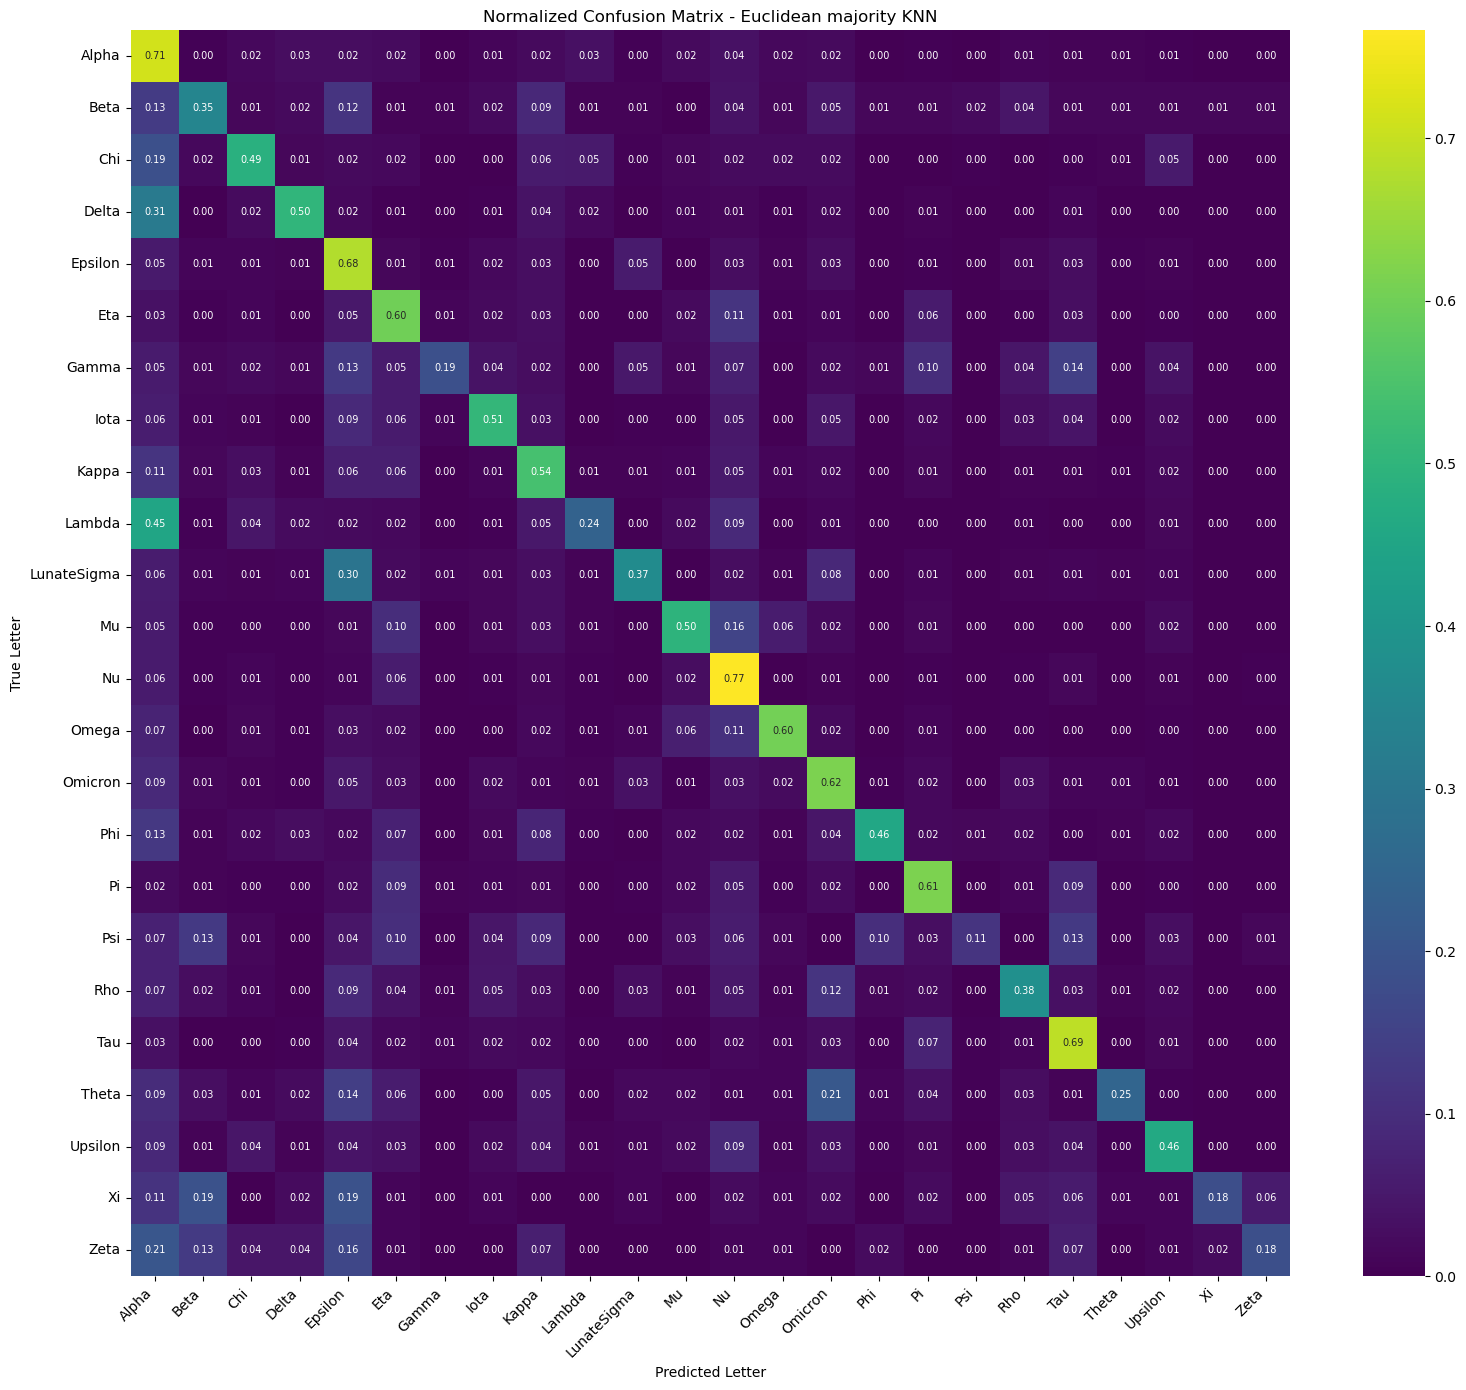

In [6]:
y_pred_euclidean_majority = predict_knn_euclidean(
    X_train_scaled,
    y_train,
    X_test_scaled,
    n_classes=n_classes,
    k=CONFIG["n_neighbors"],
    batch_size=CONFIG["batch_size"],
    weighted=False,
)

metrics_euclidean_majority = evaluate_approach(
    "Euclidean majority KNN",
    y_test,
    y_pred_euclidean_majority,
)
plot_confusion_matrix("Euclidean majority KNN", y_test, y_pred_euclidean_majority)


## Approach 2: Euclidean distance-weighted KNN

This variant also uses Euclidean distance, but closer neighbors receive stronger voting weights. A very close neighbor can therefore matter more than a farther neighbor.


Predicted 640/11066
Predicted 1280/11066
Predicted 1920/11066
Predicted 2560/11066
Predicted 3200/11066
Predicted 3840/11066
Predicted 4480/11066
Predicted 5120/11066
Predicted 5760/11066
Predicted 6400/11066
Predicted 7040/11066
Predicted 7680/11066
Predicted 8320/11066
Predicted 8960/11066
Predicted 9600/11066
Predicted 10240/11066
Predicted 10880/11066
Predicted 11066/11066
Results for Euclidean distance-weighted KNN
Accuracy:    0.5667
Macro-F1:    0.4956
Weighted-F1: 0.5581

Classification report per class:
              precision    recall  f1-score   support

       Alpha     0.5423    0.6520    0.5921      1043
        Beta     0.4083    0.2988    0.3451       164
         Chi     0.5618    0.4653    0.5090       303
       Delta     0.7065    0.5186    0.5982       376
     Epsilon     0.5379    0.6518    0.5894       784
         Eta     0.4858    0.5789    0.5283       532
       Gamma     0.4118    0.1687    0.2393       166
        Iota     0.6175    0.5219    0.5657      

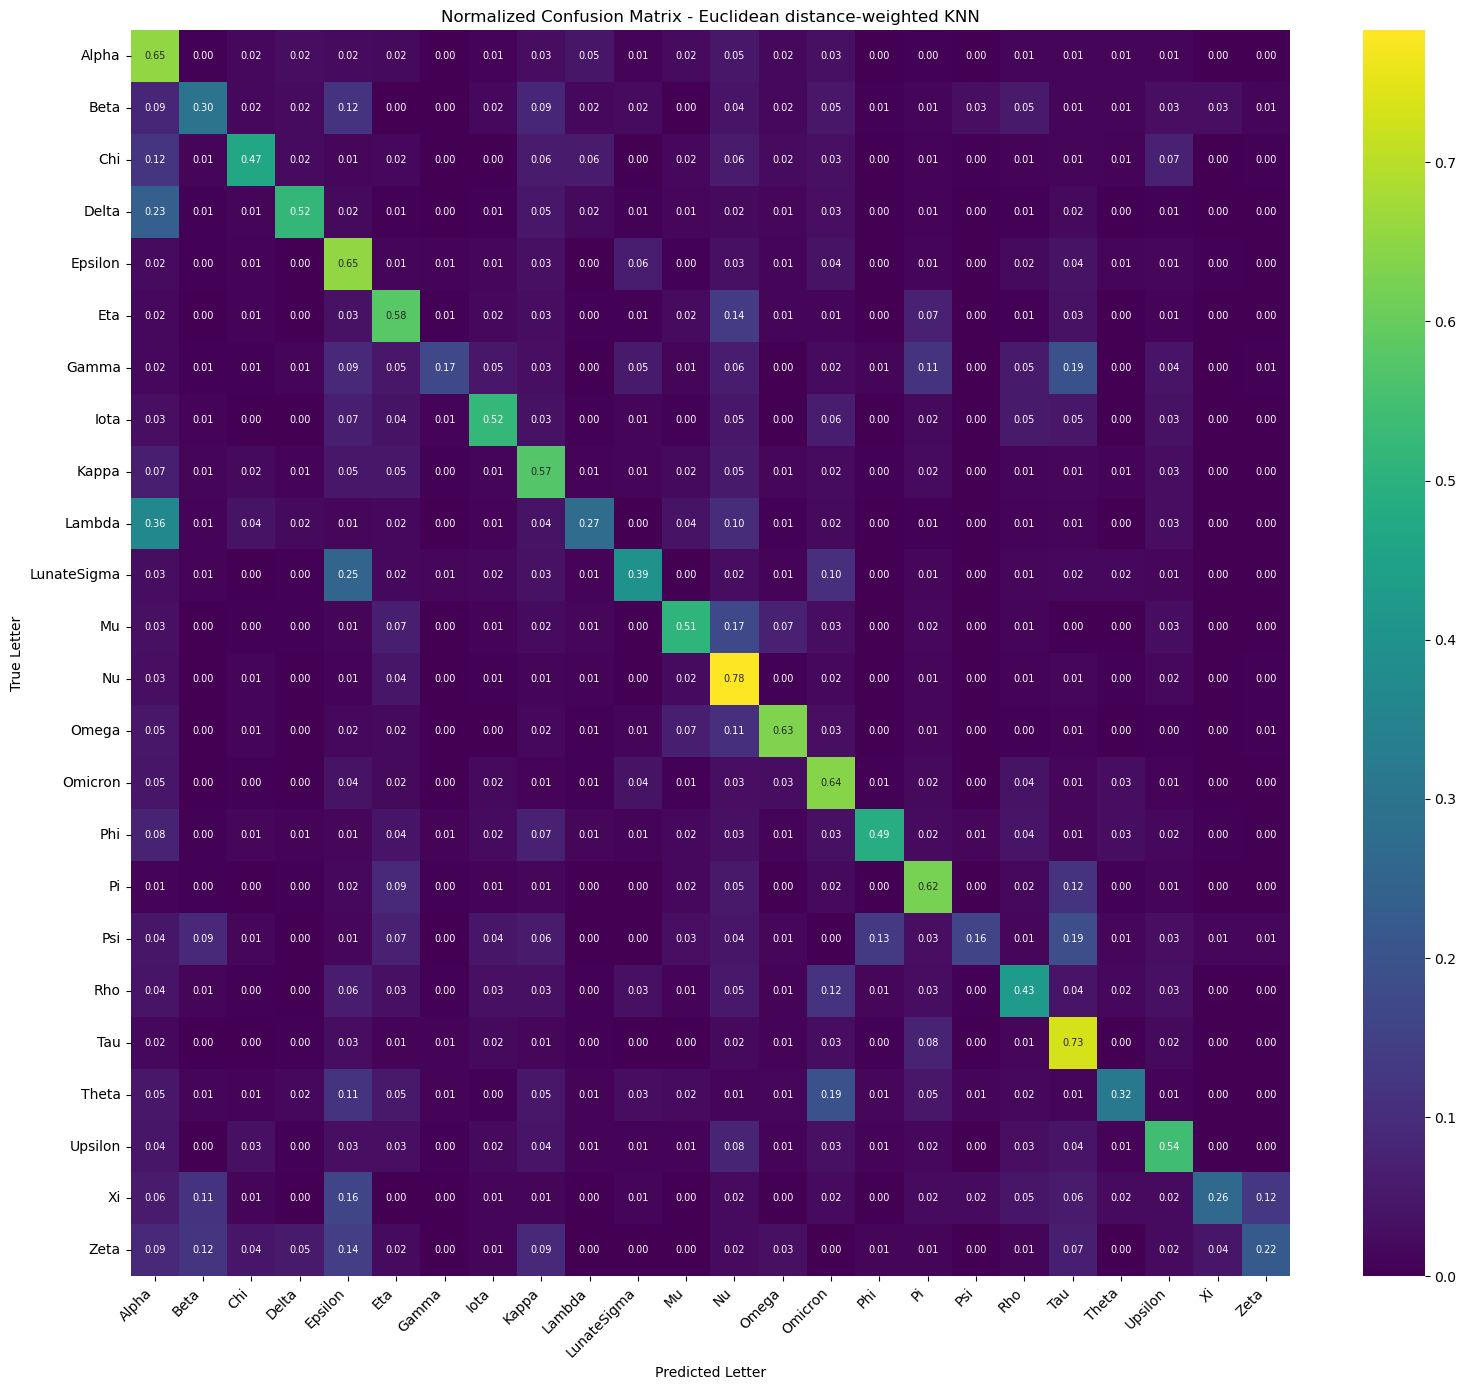

In [7]:
y_pred_euclidean_weighted = predict_knn_euclidean(
    X_train_scaled,
    y_train,
    X_test_scaled,
    n_classes=n_classes,
    k=CONFIG["n_neighbors"],
    batch_size=CONFIG["batch_size"],
    weighted=True,
)

metrics_euclidean_weighted = evaluate_approach(
    "Euclidean distance-weighted KNN",
    y_test,
    y_pred_euclidean_weighted,
)
plot_confusion_matrix("Euclidean distance-weighted KNN", y_test, y_pred_euclidean_weighted)


## Approach 3: Cosine distance-weighted KNN

This variant compares the direction of the feature vectors instead of their absolute Euclidean distance. This can be useful for neural-network features, where the activation pattern can matter more than vector magnitude.


Predicted 640/11066
Predicted 1280/11066
Predicted 1920/11066
Predicted 2560/11066
Predicted 3200/11066
Predicted 3840/11066
Predicted 4480/11066
Predicted 5120/11066
Predicted 5760/11066
Predicted 6400/11066
Predicted 7040/11066
Predicted 7680/11066
Predicted 8320/11066
Predicted 8960/11066
Predicted 9600/11066
Predicted 10240/11066
Predicted 10880/11066
Predicted 11066/11066
Results for Cosine distance-weighted KNN
Accuracy:    0.5662
Macro-F1:    0.4960
Weighted-F1: 0.5570

Classification report per class:
              precision    recall  f1-score   support

       Alpha     0.5690    0.6088    0.5882      1043
        Beta     0.3701    0.2866    0.3230       164
         Chi     0.4685    0.6139    0.5314       303
       Delta     0.6946    0.5505    0.6142       376
     Epsilon     0.5517    0.6735    0.6065       784
         Eta     0.5503    0.5865    0.5678       532
       Gamma     0.4507    0.1928    0.2700       166
        Iota     0.4899    0.6143    0.5451       43

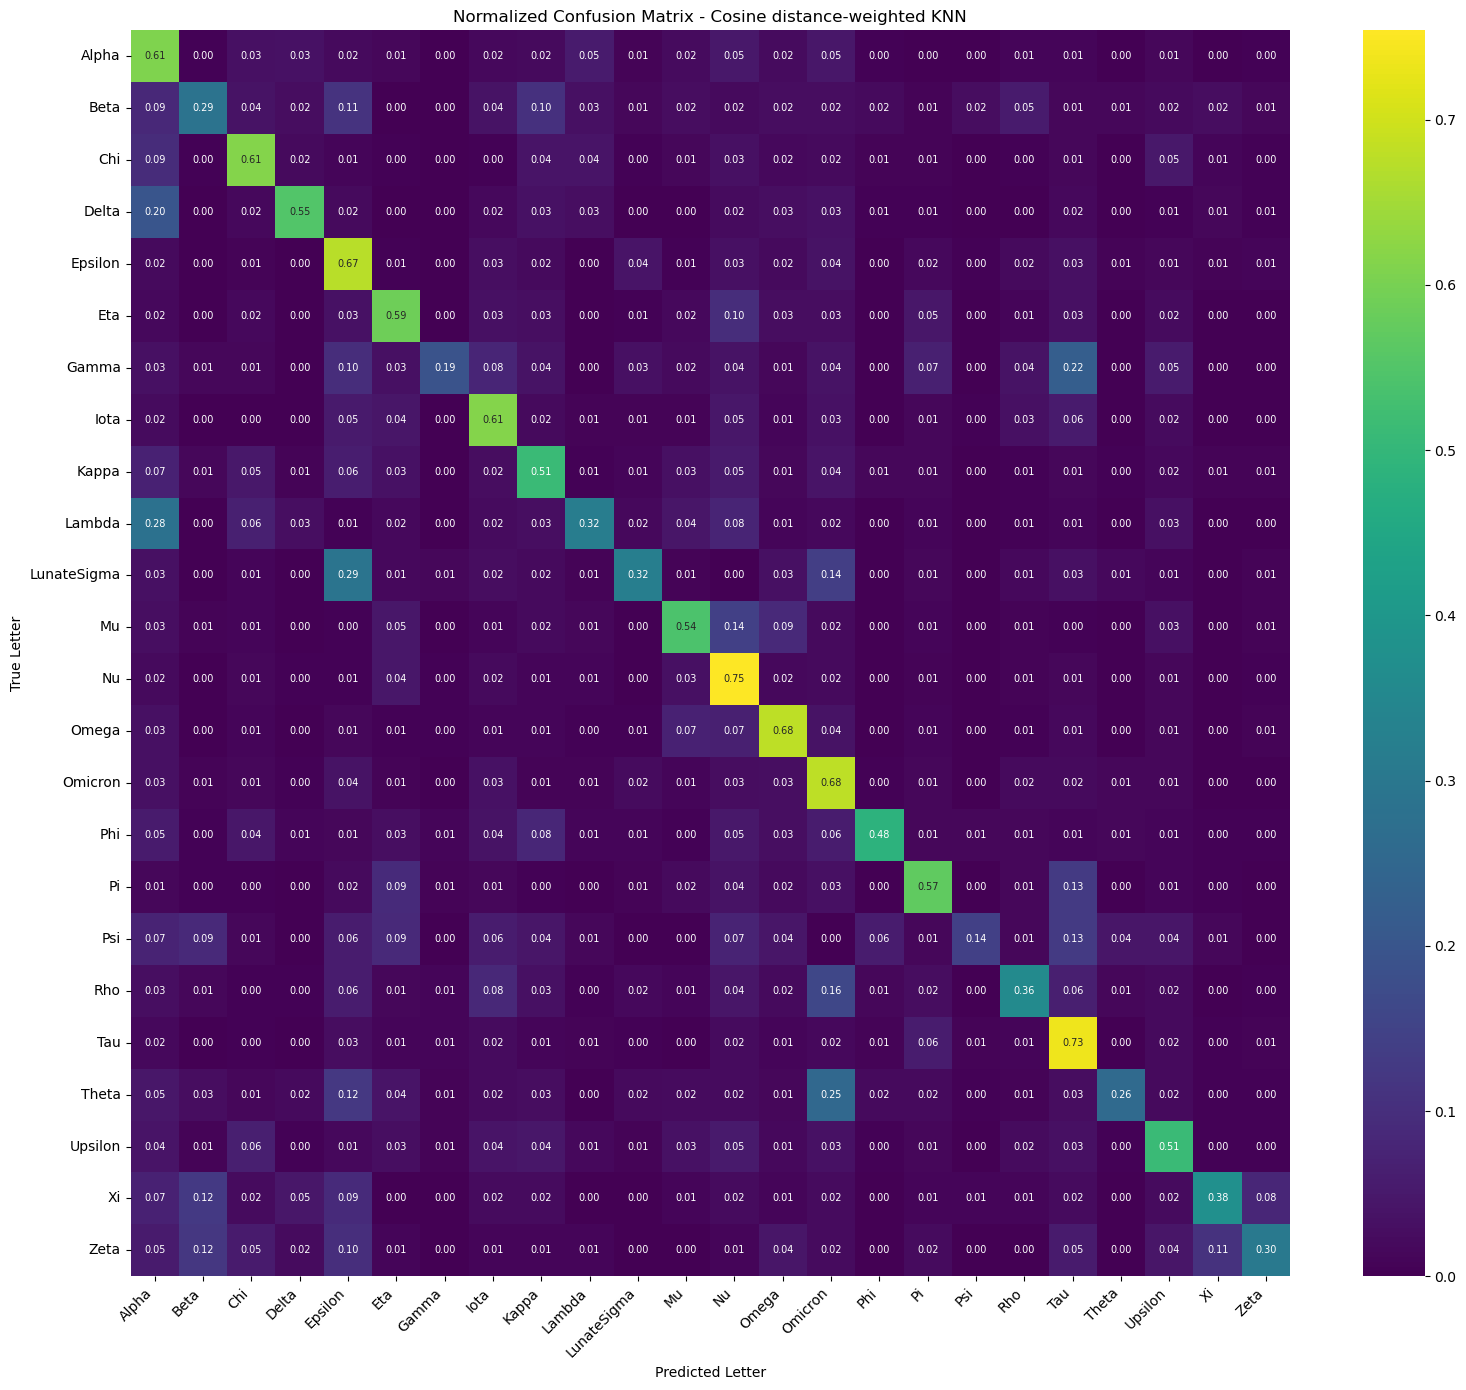

In [8]:
y_pred_cosine_weighted = predict_knn_cosine_weighted(
    X_train_scaled,
    y_train,
    X_test_scaled,
    n_classes=n_classes,
    k=CONFIG["n_neighbors"],
    batch_size=CONFIG["batch_size"],
)

metrics_cosine_weighted = evaluate_approach(
    "Cosine distance-weighted KNN",
    y_test,
    y_pred_cosine_weighted,
)
plot_confusion_matrix("Cosine distance-weighted KNN", y_test, y_pred_cosine_weighted)


## Approach 4: Small hyperparameter tuning

This adds a compact `GridSearchCV` on the same training split. The search stays intentionally small: a few `k` values, three distance metrics, and both voting schemes. `macro_f1` is used as the CV target so every class matters equally.


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best CV macro-F1: 0.4915
Best params:
  knn__metric: euclidean
  knn__n_neighbors: 11
  knn__weights: distance
  normalizer: passthrough


C:\Users\marti\miniconda3\envs\odysseus\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Results for Tuned KNN (euclidean, k=11, distance)
Accuracy:    0.5795
Macro-F1:    0.5019
Weighted-F1: 0.5688

Classification report per class:
              precision    recall  f1-score   support

       Alpha     0.5314    0.6731    0.5939      1043
        Beta     0.3894    0.2683    0.3177       164
         Chi     0.6228    0.4686    0.5348       303
       Delta     0.7423    0.5133    0.6069       376
     Epsilon     0.5389    0.6709    0.5977       784
         Eta     0.4938    0.5996    0.5416       532
       Gamma     0.5556    0.1807    0.2727       166
        Iota     0.6311    0.5335    0.5782       433
       Kappa     0.5680    0.6000    0.5835       585
      Lambda     0.4740    0.2571    0.3333       354
 LunateSigma     0.5081    0.3896    0.4410       403
          Mu     0.6417    0.5031    0.5640       477
          Nu     0.5638    0.8179    0.6675       972
       Omega     0.7120    0.6476    0.6783       542
     Omicron     0.6276    0.6593    0.6431  

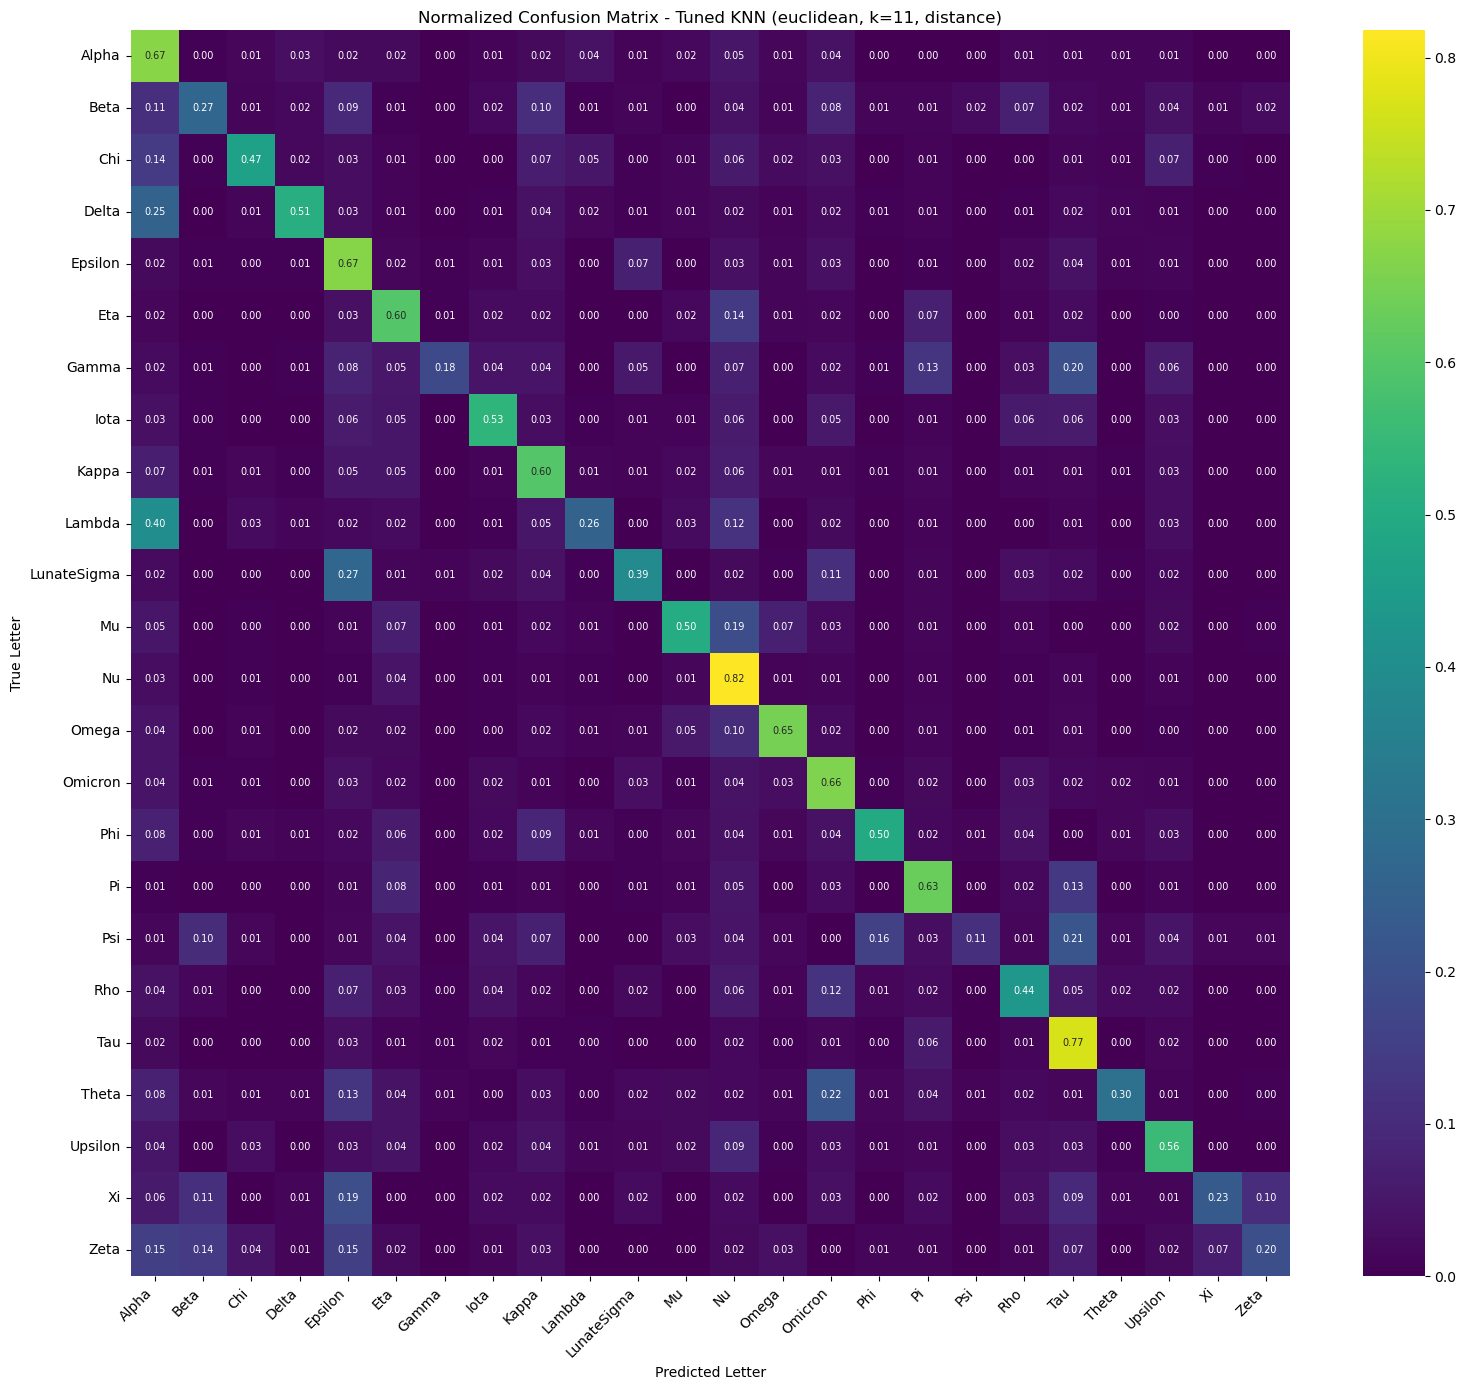

In [9]:
tuning_pipeline = Pipeline([
    ("normalizer", "passthrough"),
    ("knn", KNeighborsClassifier(algorithm="brute")),
])

param_grid = [
    {
        "normalizer": ["passthrough"],
        "knn__n_neighbors": CONFIG["tuning_neighbors"],
        "knn__weights": ["uniform", "distance"],
        "knn__metric": ["euclidean", "manhattan"],
    },
    {
        "normalizer": [Normalizer()],
        "knn__n_neighbors": CONFIG["tuning_neighbors"],
        "knn__weights": ["uniform", "distance"],
        "knn__metric": ["cosine"],
    },
]

cv = StratifiedKFold(
    n_splits=CONFIG["tuning_cv_folds"],
    shuffle=True,
    random_state=CONFIG["random_state"],
)

grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train_scaled, y_train)

best_params = grid_search.best_params_.copy()
best_params["normalizer"] = type(best_params["normalizer"]).__name__ if best_params["normalizer"] != "passthrough" else "passthrough"

print("Best CV macro-F1:", f"{grid_search.best_score_:.4f}")
print("Best params:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

y_pred_tuned = grid_search.predict(X_test_scaled)
approach_name = f"Tuned KNN ({best_params['knn__metric']}, k={best_params['knn__n_neighbors']}, {best_params['knn__weights']})"
metrics_tuned = evaluate_approach(approach_name, y_test, y_pred_tuned)
metrics_tuned["cv_macro_f1"] = grid_search.best_score_
plot_confusion_matrix(approach_name, y_test, y_pred_tuned)


## Final comparison

Macro-F1 is a useful main metric here because it gives every class equal importance. Accuracy and weighted-F1 can be influenced more strongly by frequent classes.


In [10]:
results_df = pd.DataFrame([
    metrics_euclidean_majority,
    metrics_euclidean_weighted,
    metrics_cosine_weighted,
    metrics_tuned,
]).sort_values("macro_f1", ascending=False).reset_index(drop=True)

results_df


,approach,accuracy,macro_f1,weighted_f1,cv_macro_f1
0,"Tuned KNN (euclidean, k=11, distance)",0.579523,0.501937,0.568811,0.491515
1,Cosine distance-weighted KNN,0.566239,0.496015,0.557014,NaN
2,Euclidean distance-weighted KNN,0.566691,0.495571,0.558055,NaN
3,Euclidean majority KNN,0.554762,0.481268,0.546205,NaN


In [11]:
best = results_df.iloc[0]
print("Best approach by Macro-F1:")
print(f"Approach:    {best['approach']}")
print(f"Accuracy:    {best['accuracy']:.4f}")
print(f"Macro-F1:    {best['macro_f1']:.4f}")
print(f"Weighted-F1: {best['weighted_f1']:.4f}")


Best approach by Macro-F1:
Approach:    Tuned KNN (euclidean, k=11, distance)
Accuracy:    0.5795
Macro-F1:    0.5019
Weighted-F1: 0.5688
